In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, splev, splrep
import seaborn as sns
sns.set_style('darkgrid')

In [65]:
ventas_locales_AB = pd.read_csv('DosLocales_Ciclica_2.csv')
ventas_locales_AB.head()

,X,t,localA,localB
0,1,40,8.610292,11.980713
1,2,41,11.064827,13.406117
2,3,42,10.349431,13.369178
3,4,43,10.679071,12.700395
4,5,44,10.318347,13.389946


In [66]:
N = len(ventas_locales_AB)
print(f"Tamaño de muestra: {N}")

Tamaño de muestra: 21


# 1. Aumentar frecuencia de muestreo

In [67]:
t = ventas_locales_AB['t'].values
localA = ventas_locales_AB['localA'].values

new_n = 3 * N
t_new = np.linspace(t.min(), t.max(), new_n)
print(f"Nuevo tamaño de muestra: {new_n}")

Nuevo tamaño de muestra: 63


### Interpolación Lineal

In [68]:
# Crear interpolación lineal
interpolacion_lineal = interp1d(t, localA)
localA_interp_lineal = interpolacion_lineal(t_new)

In [78]:
# Interpolación cúbica (spline en R)
spline_params = splrep(t, localA)
localA_interp_cubica = splev(t_new, spline_params)

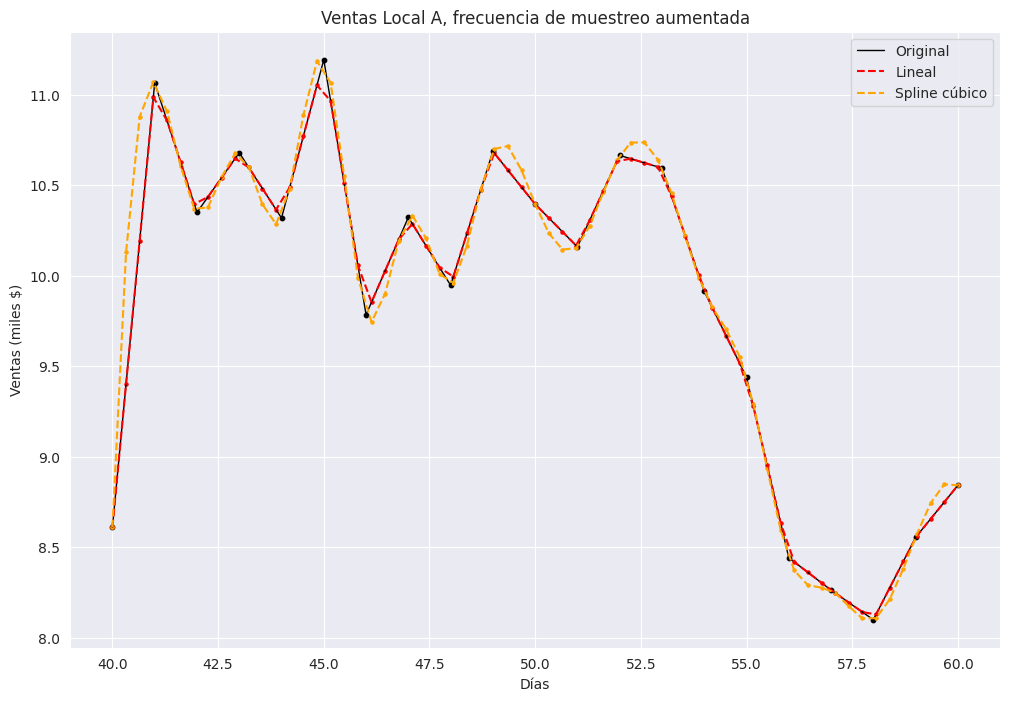

In [79]:
plt.figure(figsize=(12, 8))

# Original (línea sólida negra)
sns.lineplot(x=t, y=localA, label='Original', color='black', linestyle='-', linewidth=1)
plt.scatter(t, localA, color='black', s=10)

# Aproximación lineal (rojo discontinua + puntos)
sns.lineplot(x=t_new, y=localA_interp_lineal, color='red', label='Lineal (approx)', linestyle='--')
plt.scatter(t_new, localA_interp_lineal, color='red', s=5)

# Spline cúbico (naranja discontinua + puntos)
sns.lineplot(x=t_new, y=localA_interp_cubica, color='orange', label='Spline cúbico', linestyle='--')
plt.scatter(t_new, localA_interp_cubica, color='orange', s=5)

plt.title('Ventas Local A, frecuencia de muestreo aumentada')
plt.xlabel('Días')
plt.ylabel('Ventas (miles $)')
plt.legend()
plt.grid(True)
plt.show()

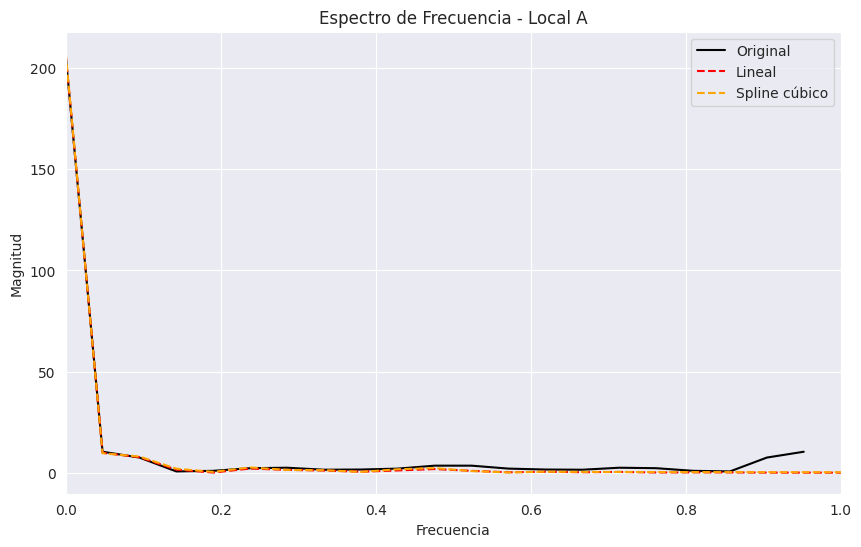

In [94]:
# FFT de las señales (magnitudes, para plotear)
fft_localA = np.abs(np.fft.fft(localA))
fft_localA_interp_lineal = np.abs(np.fft.fft(localA_interp_lineal))
fft_localA_interp_cubica = np.abs(np.fft.fft(localA_interp_cubica))

# Tiempos
tiempo = np.arange(N)
tiempo3 = np.arange(3 * N)

# Frecuencia para la original
fs_original = 1  # Frecuencia de muestreo
delta_f_original = fs_original / N
frecuencia = delta_f_original * tiempo

# Frecuencia para las interpoladas
fs_interp = 3  # Frecuencia de muestreo triplicada
delta_f_interp = fs_interp / (3 * N)
frecuencia_interp = delta_f_interp * tiempo3

# Graficar espectro
plt.figure(figsize=(10, 6))
plt.plot(frecuencia, fft_localA, label='Original', color='black')

plt.plot(frecuencia_interp, fft_localA_interp_lineal / 3, label='Lineal', color='red', linestyle='--')
plt.plot(frecuencia_interp, fft_localA_interp_cubica / 3, label='Spline cúbico', color='orange', linestyle='--')

plt.xlim(0, 1)
plt.title('Espectro de Frecuencia - Local A')
plt.xlabel('Frecuencia')
plt.ylabel('Magnitud')
plt.legend()
plt.grid(True)
plt.show()


El aumento de frecuencia de muestreo en la interpolación **no añadió componentes al espectro de frecuencia**.